In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')


In [3]:
try:
    df = pd.read_csv('dataset.csv')
    print("\nDataset loaded successfully from 'dataset.csv'")
except FileNotFoundError:
    print("\nFile 'dataset.csv' not found!")
    exit()


Dataset loaded successfully from 'dataset.csv'


In [4]:
#getting basic information about dataset
print(f"\nDataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1}")


Dataset Shape: 690 rows and 16 columns
Number of samples: 690
Number of features: 15


In [5]:
print("\nFirst 5 rows of the dataset:")
df.head()


First 5 rows of the dataset:


,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1.0,1,Industrials,White,1.25,1,1.0,1,0,ByBirth,202,0.0,1
1,0,58.67,4.460,1.0,1,Materials,Black,3.04,1,1.0,6,0,ByBirth,43,560.0,1
2,0,24.5,0.500,1.0,1,Materials,Black,1.50,1,0.0,0,0,ByBirth,280,824.0,1
3,1,27.83,1.540,1.0,1,Industrials,White,3.75,1,1.0,5,1,ByBirth,100,3.0,1
4,1,20.17,5.625,1.0,1,Industrials,White,1.71,1,0.0,0,0,ByOtherMeans,120,0.0,1


In [6]:
print("\nColumn Information:")
df.dtypes.to_frame(name='DataType')


Column Information:


,DataType
Gender,int64
Age,object
Debt,float64
Married,float64
BankCustomer,int64
Industry,object
Ethnicity,object
YearsEmployed,float64
PriorDefault,int64
Employed,float64


In [7]:
print("\nMissing Values Count:")

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if len(missing_values) > 0:
    missing_table = missing_values.to_frame(name='MissingCount').reset_index()
    missing_table = missing_table.rename(columns={'index':'Column'})
    print(missing_table)
else:
    print("No missing values found!")


Missing Values Count:
     Column  MissingCount
0       Age             4
1   Married            10
2  Employed             8
3    Income             2


In [26]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


In [30]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_summary = []
    
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100
    
    # Calculate mean and std for context
    mean_val = df[col].mean()
    std_val = df[col].std()
    
    outlier_summary.append({
        'Column': col,
        'OutlierCount': outlier_count,
        'OutlierPercentage': f"{outlier_percentage:.2f}%",
        'Mean': f"{mean_val:.4f}",
        'StdDev': f"{std_val:.4f}",
        'LowerBound': f"{lower_bound:.4f}",
        'UpperBound': f"{upper_bound:.4f}",
        'Min': df[col].min(),
        'Max': df[col].max()
    })
    
    
    if outlier_count > 0:
        print(f"Column: {col}")
        print(f"Outlier Count: {outlier_count} ({outlier_percentage:.2f}%)")
        print(f"Normal Range: [{lower_bound:.4f}, {upper_bound:.4f}]")
        print(f"Data Range: [{df[col].min():.4f}, {df[col].max():.4f}]")
        
        
        outlier_values = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        
        
        low_outliers = outlier_values[outlier_values < lower_bound]
        high_outliers = outlier_values[outlier_values > upper_bound]
        
        if len(low_outliers) > 0:
            print(f"\nLow Outliers ({len(low_outliers)} values):")
            print(f"   Values: {low_outliers.sort_values().tolist()[:10]}")  # Show first 10
            if len(low_outliers) > 10:
                print(f"   ... and {len(low_outliers) - 10} more")
        
        if len(high_outliers) > 0:
            print(f"\nHigh Outliers ({len(high_outliers)} values):")
            print(f"   Values: {high_outliers.sort_values(ascending=False).tolist()[:10]}")  # Show first 10
            if len(high_outliers) > 10:
                print(f"   ... and {len(high_outliers) - 10} more")
        
# Create summary dataframe
outlier_df = pd.DataFrame(outlier_summary)

# Display overall summary
print(f"\n{'='*60}")
print("SUMMARY - COLUMNS WITH OUTLIERS")
print(f"{'='*60}")
print(outlier_df[outlier_df['OutlierCount'] > 0].to_string(index=False))

Column: Age
Outlier Count: 19 (2.76%)
Normal Range: [0.4250, 59.7450]
Data Range: [13.7500, 80.2500]

High Outliers (19 values):
   Values: [80.25, 76.75, 74.83, 73.42, 71.58, 69.5, 69.17, 68.67, 67.75, 65.42]
   ... and 9 more
Column: Debt
Outlier Count: 17 (2.47%)
Normal Range: [-8.4688, 16.7812]
Data Range: [0.0000, 28.0000]

High Outliers (17 values):
   Values: [28.0, 26.335, 25.21, 25.125, 25.085, 22.29, 22.0, 21.5, 21.0, 20.0]
   ... and 7 more
Column: Married
Outlier Count: 163 (23.69%)
Normal Range: [1.0000, 1.0000]
Data Range: [0.0000, 1.0000]

Low Outliers (163 values):
   Values: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
   ... and 153 more
Column: BankCustomer
Outlier Count: 162 (23.55%)
Normal Range: [1.0000, 1.0000]
Data Range: [0.0000, 1.0000]

Low Outliers (162 values):
   Values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
   ... and 152 more
Column: YearsEmployed
Outlier Count: 63 (9.16%)
Normal Range: [-3.5250, 6.3150]
Data Range: [0.0000, 28.5000]

High Outliers (63 va

In [9]:
print("\nTarget Variable (Approved) Distribution:")
target_counts = df['Approved'].value_counts()
print(f"  Not Approved (0): {target_counts.get(0, 0)} ({target_counts.get(0, 0)/len(df)*100:.2f}%)")
print(f"  Approved (1): {target_counts.get(1, 0)} ({target_counts.get(1, 0)/len(df)*100:.f}%)")


Target Variable (Approved) Distribution:
  Not Approved (0): 383 (55.51%)
  Approved (1): 307 (44.49%)


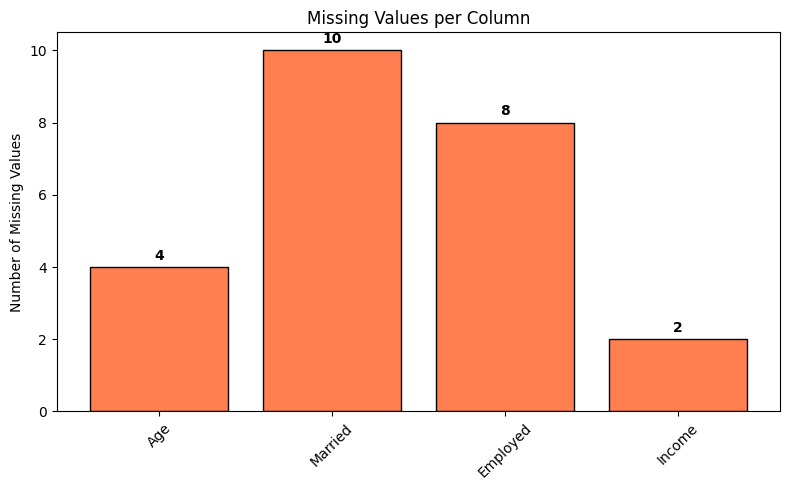


Missing Values:
  Age: 4
  Married: 10
  Employed: 8
  Income: 2


In [10]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

plt.figure(figsize=(8, 5))
plt.bar(missing_counts.index, missing_counts.values, color='coral', edgecolor='black')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Column')
plt.xticks(rotation=45)

# Add numbers on top of bars
for i, v in enumerate(missing_counts.values):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


print("\nMissing Values:")
for col, count in missing_counts.items():
    print(f"  {col}: {count}")

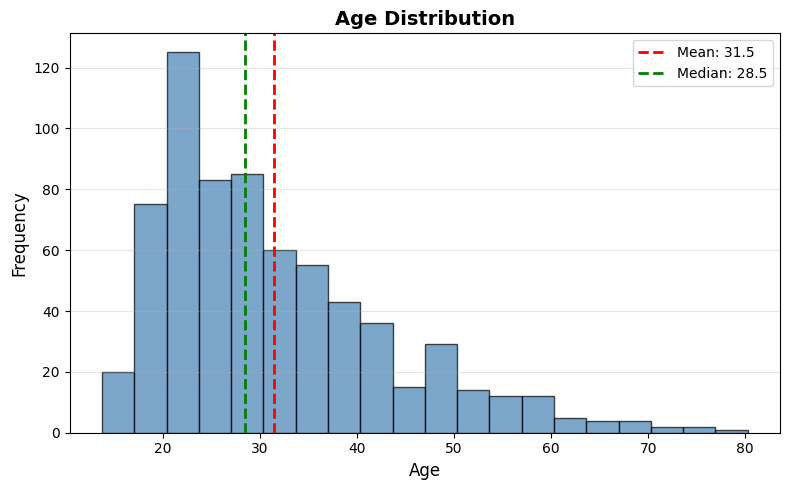

In [11]:
age_numeric = pd.to_numeric(df['Age'], errors='coerce')
age_clean = age_numeric[age_numeric.notna()]


plt.figure(figsize=(8, 5))
plt.hist(age_clean, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(age_clean.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {age_clean.mean():.1f}')
plt.axvline(age_clean.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {age_clean.median():.1f}')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

age_mean = df['Age'].median()

df['Age'].fillna(age_mean, inplace=True)


missing_after = df['Age'].isnull().sum()
print(f"Missing values after: {missing_after}")


Missing values after: 0


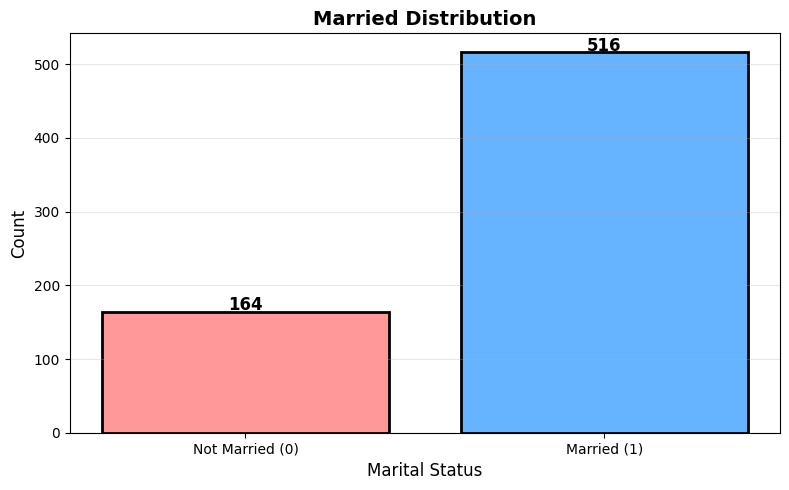

In [13]:
plt.figure(figsize=(8, 5))
married_clean = df[df['Married'].notna()]['Married']
married_counts = married_clean.value_counts()

bars = plt.bar(['Not Married (0)', 'Married (1)'], 
               [married_counts.get(0, 0), married_counts.get(1, 0)], 
               color=['#ff9999', '#66b3ff'], 
               edgecolor='black', 
               linewidth=2)

for bar, count in zip(bars, [married_counts.get(0, 0), married_counts.get(1, 0)]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             str(count), ha='center', fontweight='bold', fontsize=12)

plt.ylabel('Count', fontsize=12)
plt.xlabel('Marital Status', fontsize=12)
plt.title('Married Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
married_mode = df['Married'].mode()[0]

df['Married'].fillna(married_mode, inplace=True)

# Verify no missing values remain
missing_after = df['Married'].isnull().sum()
print(f"\nMissing values after: {missing_after}")



Missing values after: 0


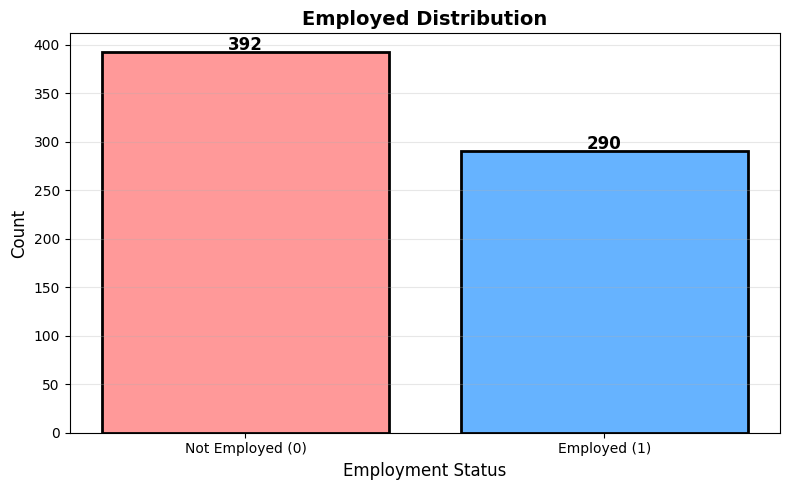

In [15]:
plt.figure(figsize=(8, 5))
employed_clean = df[df['Employed'].notna()]['Employed']
employed_counts = employed_clean.value_counts()

bars = plt.bar(['Not Employed (0)', 'Employed (1)'], 
               [employed_counts.get(0, 0), employed_counts.get(1, 0)], 
               color=['#ff9999', '#66b3ff'], 
               edgecolor='black', 
               linewidth=2)

for bar, count in zip(bars, [employed_counts.get(0, 0), employed_counts.get(1, 0)]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             str(count), ha='center', fontweight='bold', fontsize=12)

plt.ylabel('Count', fontsize=12)
plt.xlabel('Employment Status', fontsize=12)
plt.title('Employed Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
employed_mode = df['Employed'].mode()[0]

df['Employed'].fillna(employed_mode, inplace=True)

# Verify no missing values remain
missing_after = df['Employed'].isnull().sum()
print(f"\nMissing values after: {missing_after}")


Missing values after: 0


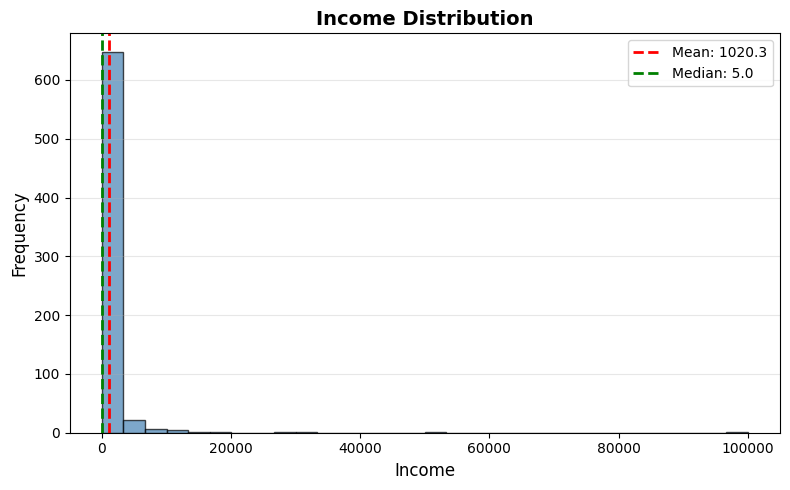

In [17]:
plt.figure(figsize=(8, 5))
income_clean = df[df['Income'].notna()]['Income']

plt.hist(income_clean, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(income_clean.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {income_clean.mean():.1f}')
plt.axvline(income_clean.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {income_clean.median():.1f}')
plt.xlabel('Income', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Income Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
df = df.dropna(subset=['Income'])

print(f"  Missing Income values: {df['Income'].isnull().sum()}")


  Missing Income values: 0


In [19]:
print("\nMissing Values Count:")

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if len(missing_values) > 0:
    missing_table = missing_values.to_frame(name='MissingCount').reset_index()
    missing_table = missing_table.rename(columns={'index':'Column'})
    print(missing_table)
else:
    print("No missing values found!")


Missing Values Count:
No missing values found!


In [20]:
categorical_cols = ['Industry', 'Ethnicity', 'Citizen']

print(f"  Dataset shape before encoding : {df.shape}")


df = pd.get_dummies(df, columns=categorical_cols, drop_first=False)


print(f"Dataset shape after encoding : {df.shape}")




  Dataset shape before encoding : (688, 16)
Dataset shape after encoding : (688, 35)


In [21]:
X = df.drop('Approved', axis=1)
y = df['Approved']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeatures: {list(X.columns[:5])}... (total {len(X.columns)} features)")
print(f"Target: Approved")

Features (X) shape: (688, 34)
Target (y) shape: (688,)

Features: ['Gender', 'Age', 'Debt', 'Married', 'BankCustomer']... (total 34 features)
Target: Approved


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=44)

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTraining approval rate: {y_train.mean()*100:.1f}%")
print(f"Test approval rate: {y_test.mean()*100:.1f}%")

Training set: 550 samples (79.9%)
Test set: 138 samples (20.1%)

Training approval rate: 44.7%
Test approval rate: 42.8%


In [23]:

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"  Training data shape: {X_train_scaled.shape}")
print(f"  Test data shape: {X_test_scaled.shape}")

Features scaled successfully!
  Training data shape: (550, 34)
  Test data shape: (138, 34)



Random Forest Results:
  Accuracy:  0.8986
  Precision: 0.8462
  Recall:    0.9322
  F1-Score:  0.8871


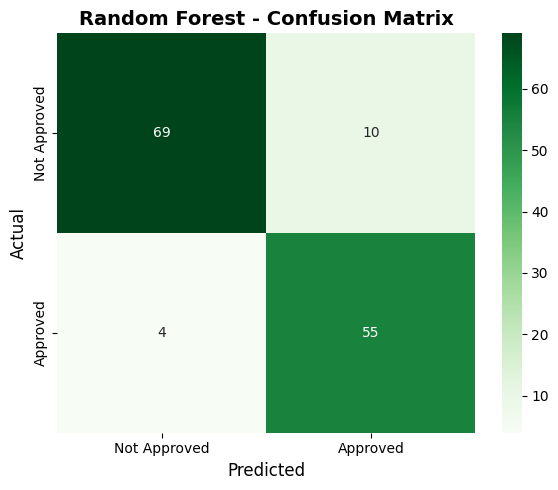

In [98]:
#RandomForest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


rf_pred = rf_model.predict(X_test)


rf_acc = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"\nRandom Forest Results:")
print(f"  Accuracy:  {rf_acc:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall:    {rf_recall:.4f}")
print(f"  F1-Score:  {rf_f1:.4f}")


rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


SVM Results:
  Accuracy:  0.8478
  Precision: 0.7639
  Recall:    0.9322
  F1-Score:  0.8397


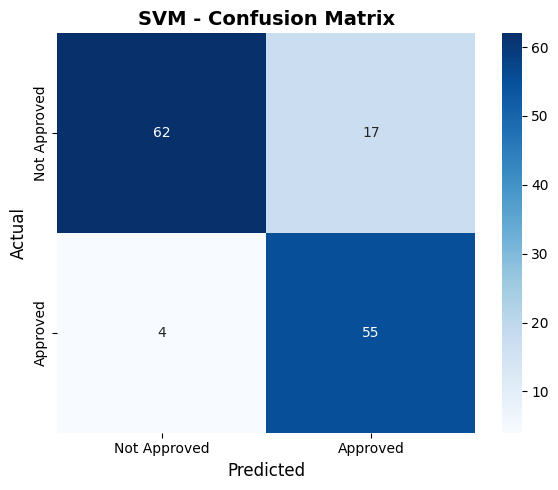

In [99]:
#svm
svm_model = SVC(kernel='rbf', random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)


svm_pred = svm_model.predict(X_test_scaled)

# Metrics
svm_acc = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print(f"\nSVM Results:")
print(f"  Accuracy:  {svm_acc:.4f}")
print(f"  Precision: {svm_precision:.4f}")
print(f"  Recall:    {svm_recall:.4f}")
print(f"  F1-Score:  {svm_f1:.4f}")

# Create and plot Confusion Matrix
svm_cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('SVM - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [107]:

data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Random Forest': [rf_acc, rf_precision, rf_recall, rf_f1],
    'SVM': [svm_acc, svm_precision, svm_recall, svm_f1]
}

df_compare = pd.DataFrame(data)

# Add Winner column
def get_winner(row):
    if row['Random Forest'] > row['SVM']:
        return 'Random Forest'
    elif row['SVM'] > row['Random Forest']:
        return 'SVM'
    else:
        return 'Tie'

df_compare['Winner'] = df_compare.apply(get_winner, axis=1)

# Round values
df_compare['Random Forest'] = df_compare['Random Forest'].round(4)
df_compare['SVM'] = df_compare['SVM'].round(4)

def highlight(row):
    if row['Random Forest'] > row['SVM']:
        return ['', 'background-color: lightgreen', '', '']
    elif row['SVM'] > row['Random Forest']:
        return ['', '', 'background-color: lightgreen', '']
    else:
        return ['', '', '', '']

df_compare.style.apply(highlight, axis=1)

,Metric,Random Forest,SVM,Winner
0,Accuracy,0.898600,0.847800,Random Forest
1,Precision,0.846200,0.763900,Random Forest
2,Recall,0.932200,0.932200,Tie
3,F1-Score,0.887100,0.839700,Random Forest


In [112]:
import pickle

In [113]:
pickle.dump(rf_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X.columns, open("columns.pkl", "wb"))

print("All files saved!")
print("Columns saved:", len(X.columns))

All files saved!
Columns saved: 34
